# Create high resolution census tract boundaries

#### Overview
This script creates high resolution census tract boundaries for use in the [national gentrification intensity map](https://github.com/johnlauermann/gentrification-intensity-map).

We'll do the same workflow to create high resolution boundaries for two Census years: 
- 2020 tract boundaries are designed to work with our primary gentrification map product, a longitudinal tract database from 1990-2020 that is geographically crosswalked to 2020 census boundaries
- 2010 tract boundaries are designed to work with a historical supplement, a longitudinal tract database from 1970-2020 that is geographically crosswalked to 2010 census boundaries

#### Rationale
While general boundary files -- for example from Census TIGER/Line or the National Historical GIS -- are fine for most analysis, high-resolution boundaries are needed for cartography to avoid gaps and more closely follow physical geographic features like shorelines.  We want to avoid issues like this: 

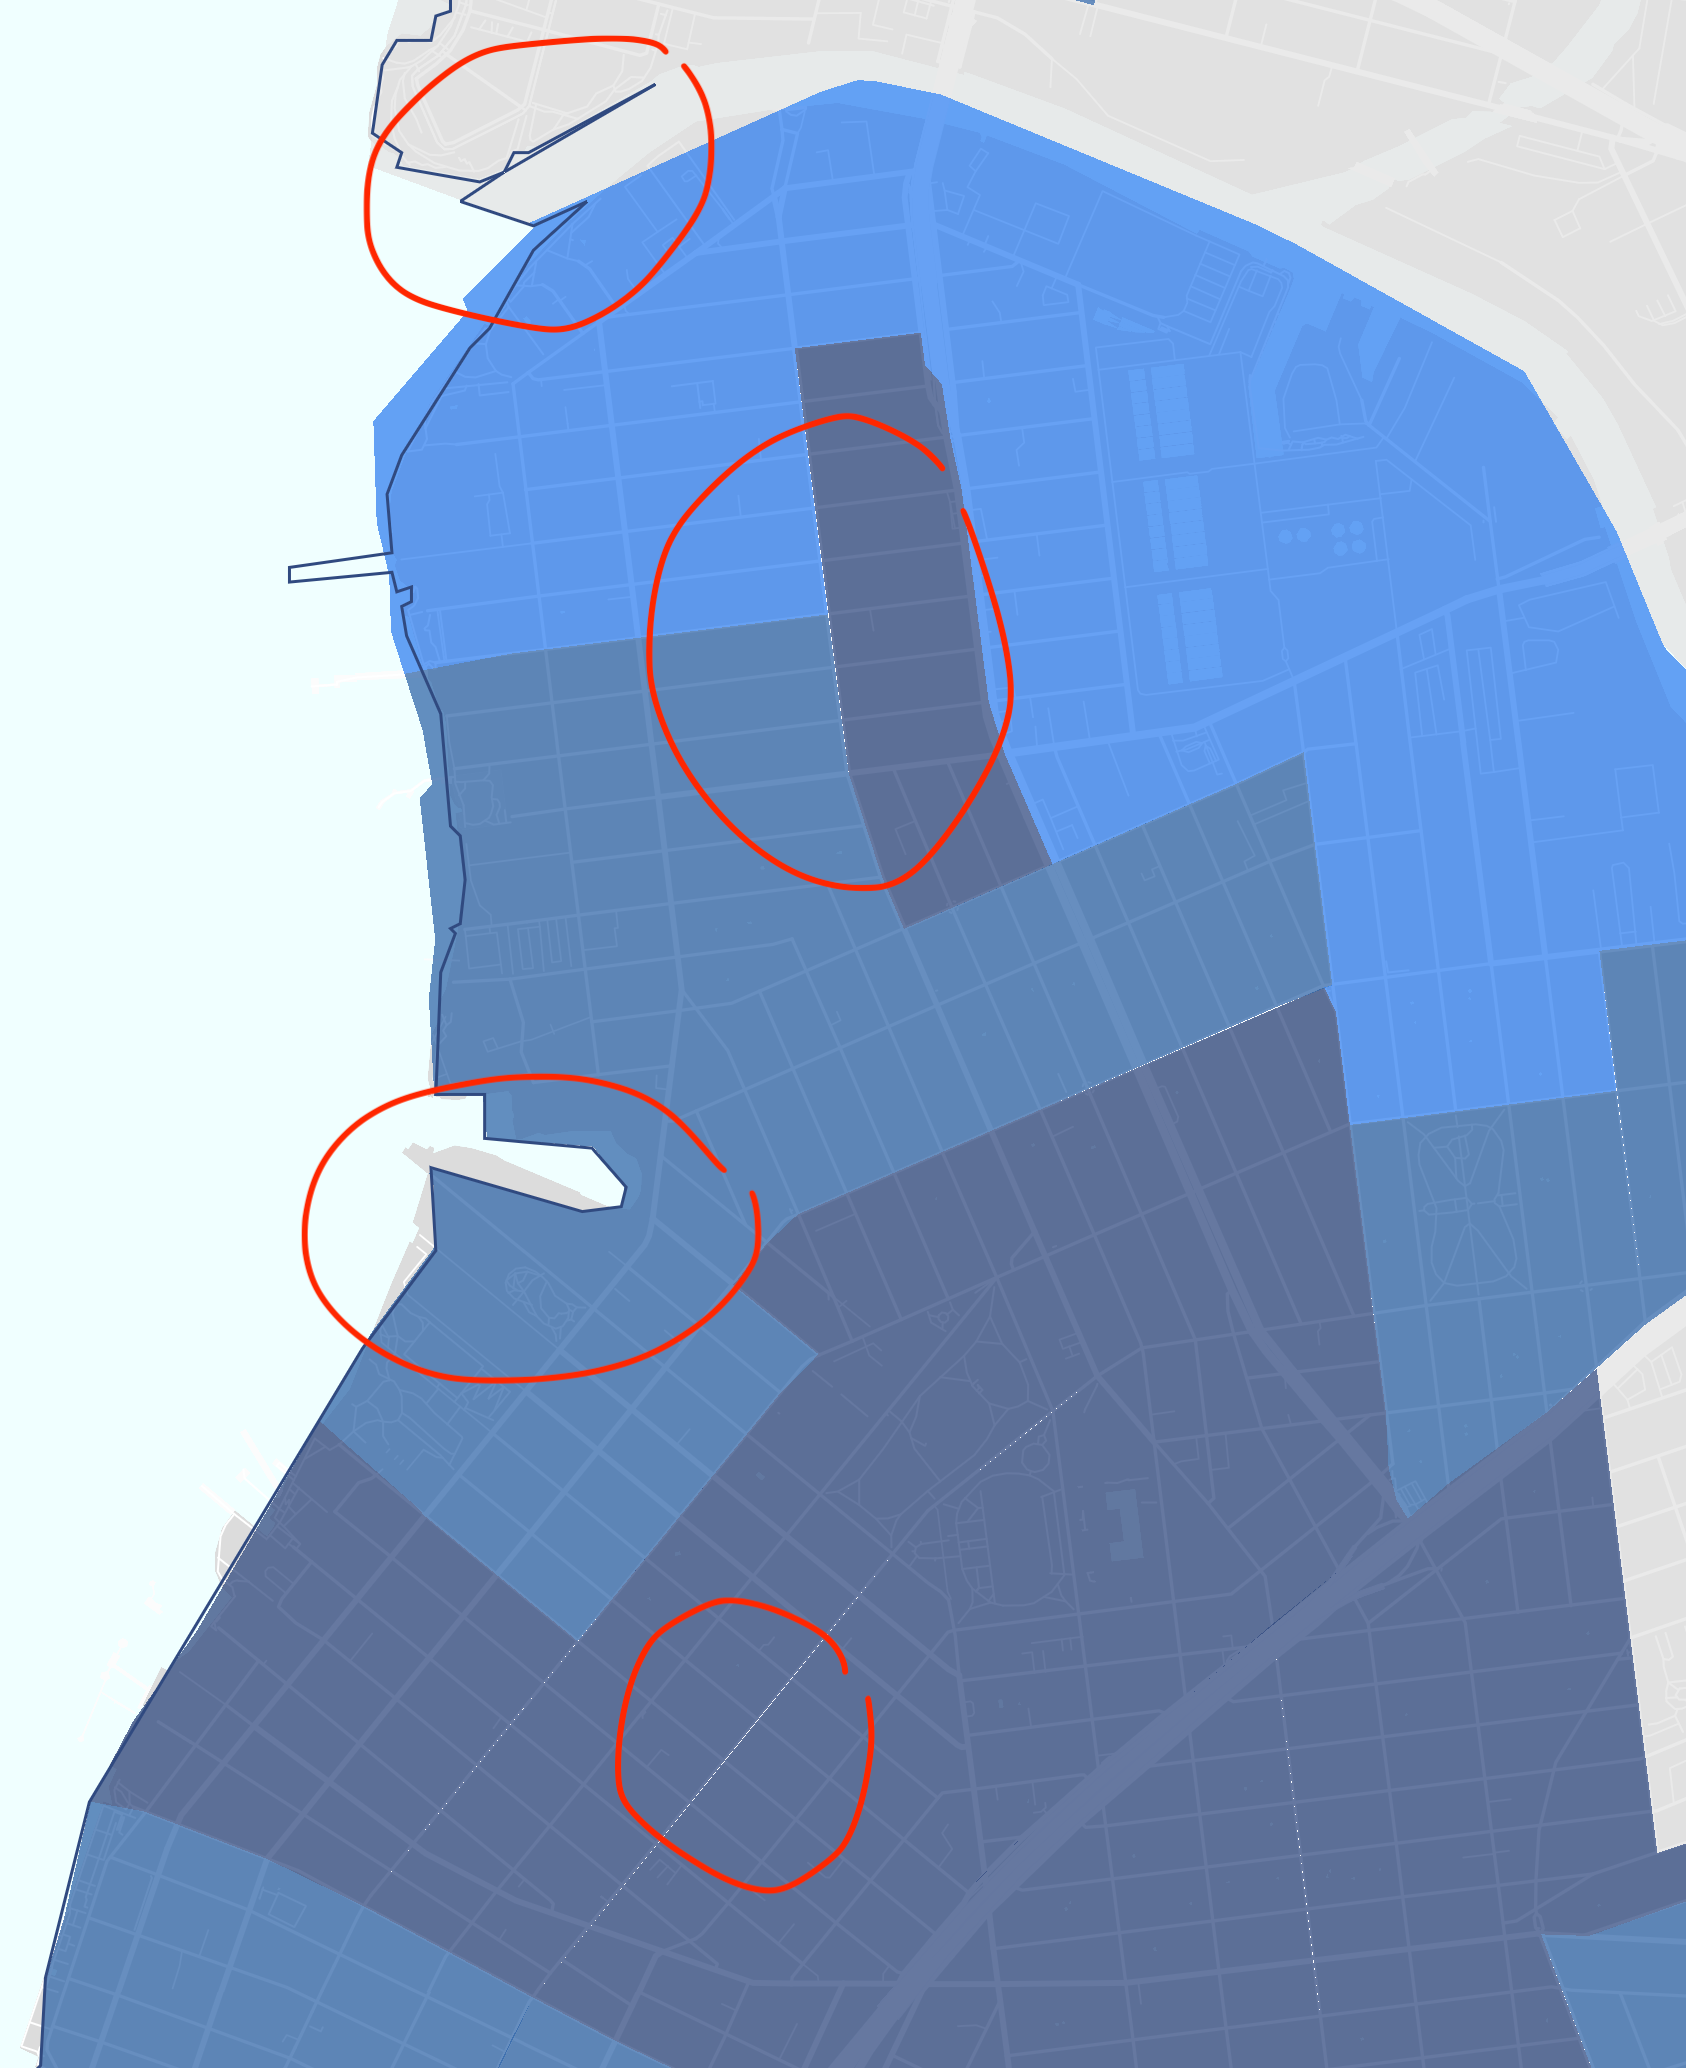

Instead, we build a custom boundary map using high resolution data products from the US Census Cartographic Boundary files program. 

# Set up
This script is designed to run on Python within ArcGIS Pro. To replicate, you can download this notebook, save it to the home folder associated with your .aprx project file, and then add the notebook to your project. Note that if you are running Python in ArcGIS for the first time, you will also need to clone your Python environment and activate the clone. The default Python environment in ArcGIS does not allow installation of new libraries. For details, here's some [ArcGIS documentation](https://pro.arcgis.com/en/pro-app/3.3/arcpy/get-started/clone-an-environment.htm).

In [ ]:
import os
import requests
import io
import zipfile
import arcpy

In [ ]:
# set up your local working environment
aprx = arcpy.mp.ArcGISProject("Current") # your current aprx file
default_gdb = aprx.defaultGeodatabase  # the default geodatabase of the aprx
default_folder = aprx.homeFolder  # the default folder of the aprx
arcpy.env.overwriteOutput = True  # allows ArcGIS to overwrite files
map = aprx.listMaps()[0] # specify which map you're using 
crs = map.spatialReference  # borrow the default projection from that map

print("Directory: " + default_folder)
print("Geodatabase: " + default_gdb)
print("Activated map: " + map.name)
print("Coordinate reference system: " + crs.name)

# 2020 Census Boundaries
This workflow draws on two boundary line data sources: 
- High resolution Census Cartographic Boundary files for 2020 census tracks (at 1:500,000 scale)
- High resolution Census Cartographic Boundary files for 2020 Areal Hydrology (for coasts and other water features)

To speed things up, we'll use `arcpy.PairwiseErase()` to cut the water areas out of the tract polygons. This method uses parallel processing and is much faster than a conventional erasure geoprocessing. 

In [ ]:
# load tract boundaries
## download the data
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_tract_500k.zip"
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as zip:
    zip.extractall("tract_boundaries")

## convert to geodatabase
with arcpy.EnvManager(outputCoordinateSystem='PROJCRS["USA_Contiguous_Albers_Equal_Area_Conic",BASEGEOGCRS["GCS_North_American_1983",DATUM["D_North_American_1983",ELLIPSOID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],CS[ellipsoidal,2],AXIS["Latitude (lat)",north,ORDER[1]],AXIS["Longitude (lon)",east,ORDER[2]],ANGLEUNIT["Degree",0.0174532925199433]],CONVERSION["Albers",METHOD["Albers"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-96.0],PARAMETER["Standard_Parallel_1",29.5],PARAMETER["Standard_Parallel_2",45.5],PARAMETER["Latitude_Of_Origin",37.5]],CS[Cartesian,2],AXIS["Easting (X)",east,ORDER[1]],AXIS["Northing (Y)",north,ORDER[2]],LENGTHUNIT["Meter",1.0],ID["Esri","102003"]]'):
    arcpy.conversion.FeatureClassToGeodatabase(
        Input_Features = os.path.join(default_folder, "tract_boundaries/cb_2020_us_tract_500k.shp"),
        Output_Geodatabase = default_gdb)

In [ ]:
# load water areas
## download the data
url = "https://www2.census.gov/geo/tiger/TGRGDB25/tlgdb_2025_a_us_areawater.gdb.zip"
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as zip:
    zip.extractall("areal_hydrography")
    
## convert to geodatabase
with arcpy.EnvManager(outputCoordinateSystem='PROJCRS["WGS_1984_Web_Mercator_Auxiliary_Sphere",BASEGEOGCRS["GCS_WGS_1984",DYNAMIC[FRAMEEPOCH[1990.5],MODEL["AM0-2"]],DATUM["D_WGS_1984",ELLIPSOID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],CS[ellipsoidal,2],AXIS["Latitude (lat)",north,ORDER[1]],AXIS["Longitude (lon)",east,ORDER[2]],ANGLEUNIT["Degree",0.0174532925199433]],CONVERSION["Mercator_Auxiliary_Sphere",METHOD["Mercator_Auxiliary_Sphere"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",0.0],PARAMETER["Standard_Parallel_1",0.0],PARAMETER["Auxiliary_Sphere_Type",0.0]],CS[Cartesian,2],AXIS["Easting (X)",east,ORDER[1]],AXIS["Northing (Y)",north,ORDER[2]],LENGTHUNIT["Meter",1.0],ID["EPSG","3857"]]'):
    arcpy.conversion.FeatureClassToGeodatabase(
        Input_Features = os.path.join(default_folder, "\areal_hydrography\tlgdb_2025_a_us_areawater.gdb\Areal_Hydrography"),
        Output_Geodatabase =  default_gdb")

In [ ]:
# pairwise erase
with arcpy.EnvManager(outputCoordinateSystem='PROJCRS["USA_Contiguous_Albers_Equal_Area_Conic",BASEGEOGCRS["GCS_North_American_1983",DATUM["D_North_American_1983",ELLIPSOID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],CS[ellipsoidal,2],AXIS["Latitude (lat)",north,ORDER[1]],AXIS["Longitude (lon)",east,ORDER[2]],ANGLEUNIT["Degree",0.0174532925199433]],CONVERSION["Albers",METHOD["Albers"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-96.0],PARAMETER["Standard_Parallel_1",29.5],PARAMETER["Standard_Parallel_2",45.5],PARAMETER["Latitude_Of_Origin",37.5]],CS[Cartesian,2],AXIS["Easting (X)",east,ORDER[1]],AXIS["Northing (Y)",north,ORDER[2]],LENGTHUNIT["Meter",1.0],ID["Esri","102003"]]'):
    arcpy.analysis.PairwiseErase(
        in_features = os.path.join(default_gdb, "cb_2020_us_tract_500k"),
        erase_features = os.path.join(default_gdb, "Areal_Hydrography"),
        out_feature_class = os.path.join(default_gdb, "tracts_highres_2020tr"),
        cluster_tolerance=None
    )

In [ ]:
# export to geopackage
with arcpy.EnvManager(outputCoordinateSystem='PROJCRS["USA_Contiguous_Albers_Equal_Area_Conic",BASEGEOGCRS["GCS_North_American_1983",DATUM["D_North_American_1983",ELLIPSOID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],CS[ellipsoidal,2],AXIS["Latitude (lat)",north,ORDER[1]],AXIS["Longitude (lon)",east,ORDER[2]],ANGLEUNIT["Degree",0.0174532925199433]],CONVERSION["Albers",METHOD["Albers"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-96.0],PARAMETER["Standard_Parallel_1",29.5],PARAMETER["Standard_Parallel_2",45.5],PARAMETER["Latitude_Of_Origin",37.5]],CS[Cartesian,2],AXIS["Easting (X)",east,ORDER[1]],AXIS["Northing (Y)",north,ORDER[2]],LENGTHUNIT["Meter",1.0],ID["Esri","102003"]]'):
    arcpy.conversion.FeatureClassToGeodatabase(
        Input_Features = os.path.join(default_gdb, "tracts_highres_2020tr"),
        Output_Geodatabase os.path.join(default_folder, "tract_boundaries.gpkg")

# 2010 Census Boundaries
This workflow draws on two boundary line data sources:
- High resolution Census Cartographic Boundary files for 2010 census tracks (at 1:500,000 scale)
- High resolution Census Cartographic Boundary files for 2020 Areal Hydrology (for coasts and other water features)

In [ ]:
# define templates
state_fips = [
    "01","02","04","05","06","08","09","10","11","12","13","15","16","17","18",
    "19","20","21","22","23","24","25","26","27","28","29","30","31","32","33",
    "34","35","36","37","38","39","40","41","42","44","45","46","47","48","49",
    "50","51","53","54","55","56"
]

base_url = "https://www2.census.gov/geo/tiger/GENZ2010"

In [ ]:
# download and upzip files
shapefiles = []

for fips in state_fips:
    zipname = f"gz_2010_{fips}_140_00_500k.zip"
    url = f"{base_url}/{zipname}"
    zip_path = os.path.join(default_folder, zipname)

    print(f"Downloading {zipname} ...")
    r = requests.get(url)
    r.raise_for_status()

    with open(zip_path, "wb") as f:
        f.write(r.content)

    # unzip
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(os.path.join(default_folder, fips))

    # find shapefile
    for file in os.listdir(os.path.join(default_folder, fips)):
        if file.endswith(".shp"):
            shapefiles.append(os.path.join(default_folder, fips, file))

print(f"Found {len(shapefiles)} shapefiles")

In [ ]:
# merge into one layer
arcpy.Merge_management(inputs = shapefiles, 
                       output = os.path.join(default_gdb, "tracts2010"))

In [ ]:
# pairwise erase water
with arcpy.EnvManager(outputCoordinateSystem='PROJCRS["WGS_1984_Web_Mercator_Auxiliary_Sphere",BASEGEOGCRS["GCS_WGS_1984",DYNAMIC[FRAMEEPOCH[1990.5],MODEL["AM0-2"]],DATUM["D_WGS_1984",ELLIPSOID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],CS[ellipsoidal,2],AXIS["Latitude (lat)",north,ORDER[1]],AXIS["Longitude (lon)",east,ORDER[2]],ANGLEUNIT["Degree",0.0174532925199433]],CONVERSION["Mercator_Auxiliary_Sphere",METHOD["Mercator_Auxiliary_Sphere"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",0.0],PARAMETER["Standard_Parallel_1",0.0],PARAMETER["Auxiliary_Sphere_Type",0.0]],CS[Cartesian,2],AXIS["Easting (X)",east,ORDER[1]],AXIS["Northing (Y)",north,ORDER[2]],LENGTHUNIT["Meter",1.0],ID["EPSG","3857"]]'):
    arcpy.analysis.PairwiseErase(
        in_features=os.path.join(default_gdb, "tracts2010"),
        erase_features=os.path.join(default_gdb, "Areal_Hydrography_ExportFeatures"),
        out_feature_class=os.path.join(default_gdb, "tracts_highres_2010tr"),
        cluster_tolerance=None)

In [ ]:
# export to geopackage
with arcpy.EnvManager(outputCoordinateSystem='PROJCRS["USA_Contiguous_Albers_Equal_Area_Conic",BASEGEOGCRS["GCS_North_American_1983",DATUM["D_North_American_1983",ELLIPSOID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],CS[ellipsoidal,2],AXIS["Latitude (lat)",north,ORDER[1]],AXIS["Longitude (lon)",east,ORDER[2]],ANGLEUNIT["Degree",0.0174532925199433]],CONVERSION["Albers",METHOD["Albers"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-96.0],PARAMETER["Standard_Parallel_1",29.5],PARAMETER["Standard_Parallel_2",45.5],PARAMETER["Latitude_Of_Origin",37.5]],CS[Cartesian,2],AXIS["Easting (X)",east,ORDER[1]],AXIS["Northing (Y)",north,ORDER[2]],LENGTHUNIT["Meter",1.0],ID["Esri","102003"]]'):
    arcpy.conversion.FeatureClassToGeodatabase(
        Input_Features = os.path.join(default_gdb, "tracts_highres_2010tr"),
        Output_Geodatabase os.path.join(default_folder, "tract_boundaries.gpkg")